# SmartWaste AI — Training MobileNetV2 untuk Klasifikasi Gambar Upload

Notebook ini melatih model MobileNetV2 (transfer learning) menggunakan dataset **Garbage Classification 12 Kelas** (Mostafa Abla, Kaggle) yang di-remap menjadi 5 kelas final: **plastik, kertas, kaca, logam, organik**. Model hasil training diintegrasikan ke fitur upload gambar di Flask app.

**Catatan penting soal format simpan model:** notebook ini menyimpan model dengan format `.keras` (bukan `.h5`). Format `.h5` lama sering bentrok dengan TensorFlow 2.16+ karena perbedaan config key saat load model — kalau kamu pernah ketemu error semacam itu sebelumnya, format `.keras` ini yang menghindarinya.

**Sebelum lanjut:**
1. Set runtime ke GPU (Runtime > Change runtime type > T4 GPU).
2. Download dataset zip-nya dulu dari halaman Kaggle (tombol "Download"), simpan di komputermu — nanti diupload di Cell 2. Ukurannya cukup besar (sekitar 1-2 GB), jadi proses upload mungkin butuh beberapa menit tergantung koneksi internet.

In [ ]:
# Cell 1 — Install dependencies
!pip install split-folders -q

## 1. Upload & ekstrak dataset

Jalankan cell di bawah, lalu pilih file `.zip` dataset yang sudah kamu download dari Kaggle ketika muncul tombol "Choose Files".

In [ ]:
# Cell 2 — Upload file zip dataset & unzip
from google.colab import files

uploaded = files.upload()  # pilih file .zip dataset yang sudah kamu download dari Kaggle

zip_filename = list(uploaded.keys())[0]
!unzip -q "{zip_filename}" -d garbage_dataset

print("Selesai! Dataset ter-unzip ke folder garbage_dataset")

Saving Garbage Classification (12 classes).zip to Garbage Classification (12 classes).zip
Selesai! Dataset ter-unzip ke folder garbage_dataset


## 2. Cek struktur dataset asli (12 kelas)

In [ ]:
# Cell 3 — Cek folder & jumlah gambar per kelas
import os

RAW_DIR = "garbage_dataset/garbage_classification"

for class_name in sorted(os.listdir(RAW_DIR)):
    class_path = os.path.join(RAW_DIR, class_name)
    if os.path.isdir(class_path):
        print(f"{class_name}: {len(os.listdir(class_path))} gambar")

battery: 945 gambar
biological: 985 gambar
brown-glass: 607 gambar
cardboard: 891 gambar
clothes: 5325 gambar
green-glass: 629 gambar
metal: 769 gambar
paper: 1050 gambar
plastic: 865 gambar
shoes: 1977 gambar
trash: 697 gambar
white-glass: 775 gambar


## 3. Remap & filter ke 5 kelas final

Dataset asli punya 12 kelas. Kita gabungkan ke 5 kelas target proyek, dan **buang** kelas yang tidak relevan (`battery`, `clothes`, `shoes`, `trash`) karena tidak masuk kategori plastik/kertas/kaca/logam/organik.

In [ ]:
# Cell 4 — Remap kelas
import shutil

MAPPING = {
    "cardboard": "kertas",
    "paper": "kertas",
    "biological": "organik",
    "metal": "logam",
    "plastic": "plastik",
    "brown-glass": "kaca",
    "green-glass": "kaca",
    "white-glass": "kaca",
}
# battery, clothes, shoes, trash sengaja tidak dimasukkan (di luar 5 kelas target)

FINAL_DIR = "dataset_5class"
if os.path.exists(FINAL_DIR):
    shutil.rmtree(FINAL_DIR)

for original_class, final_class in MAPPING.items():
    src_folder = os.path.join(RAW_DIR, original_class)
    dst_folder = os.path.join(FINAL_DIR, final_class)
    os.makedirs(dst_folder, exist_ok=True)
    for fname in os.listdir(src_folder):
        src_path = os.path.join(src_folder, fname)
        dst_path = os.path.join(dst_folder, f"{original_class}_{fname}")
        shutil.copy(src_path, dst_path)

print("Hasil remap:")
for final_class in sorted(os.listdir(FINAL_DIR)):
    count = len(os.listdir(os.path.join(FINAL_DIR, final_class)))
    print(f"  {final_class}: {count} gambar")

Hasil remap:
  kaca: 2011 gambar
  kertas: 1941 gambar
  logam: 769 gambar
  organik: 985 gambar
  plastik: 865 gambar


## 4. Split train/validation/test

In [ ]:
# Cell 5 — Split dataset 80/10/10
import splitfolders

SPLIT_DIR = "dataset_split"
splitfolders.ratio(FINAL_DIR, output=SPLIT_DIR, seed=42, ratio=(.8, .1, .1))

for split in ["train", "val", "test"]:
    print(f"\n{split}:")
    split_path = os.path.join(SPLIT_DIR, split)
    for class_name in sorted(os.listdir(split_path)):
        count = len(os.listdir(os.path.join(split_path, class_name)))
        print(f"  {class_name}: {count}")

Copying files: 6571 files [00:00, 7815.90 files/s]


train:
  kaca: 1608
  kertas: 1552
  logam: 615
  organik: 788
  plastik: 692

val:
  kaca: 201
  kertas: 194
  logam: 76
  organik: 98
  plastik: 86

test:
  kaca: 202
  kertas: 195
  logam: 78
  organik: 99
  plastik: 87


## 5. Data pipeline (preprocessing + augmentasi)

Pakai `preprocess_input` bawaan MobileNetV2 supaya normalisasi pixel-nya sesuai dengan yang dipakai saat pretraining di ImageNet.

In [ ]:
# Cell 6 — ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
)
val_test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(
    f"{SPLIT_DIR}/train", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)
val_data = val_test_gen.flow_from_directory(
    f"{SPLIT_DIR}/val", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)
test_data = val_test_gen.flow_from_directory(
    f"{SPLIT_DIR}/test", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False
)

print("Mapping kelas:", train_data.class_indices)

Found 5255 images belonging to 5 classes.
Found 655 images belonging to 5 classes.
Found 661 images belonging to 5 classes.
Mapping kelas: {'kaca': 0, 'kertas': 1, 'logam': 2, 'organik': 3, 'plastik': 4}


## 6. Bangun model (MobileNetV2 transfer learning)

Base model dibekukan (`trainable = False`) dulu supaya hanya layer klasifikasi baru yang dilatih di awal — ini lebih stabil daripada langsung fine-tune seluruh network.

In [ ]:
# Cell 7 — Build model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

NUM_CLASSES = 5

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Training

`EarlyStopping` menghentikan training kalau validation loss tidak membaik selama 5 epoch, `ModelCheckpoint` menyimpan bobot terbaik secara otomatis.

In [ ]:
# Cell 8 — Train
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_mobilenetv2.keras", monitor="val_accuracy", save_best_only=True),
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks,
)

Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 110s 554ms/step - accuracy: 0.8343 - loss: 0.4538 - val_accuracy: 0.9038 - val_loss: 0.2719
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 62s 376ms/step - accuracy: 0.9060 - loss: 0.2695 - val_accuracy: 0.9160 - val_loss: 0.2448
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 62s 377ms/step - accuracy: 0.9248 - loss: 0.2163 - val_accuracy: 0.9206 - val_loss: 0.2258
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 62s 377ms/step - accuracy: 0.9321 - loss: 0.1923 - val_accuracy: 0.9328 - val_loss: 0.2060
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 62s 376ms/step - accuracy: 0.9439 - loss: 0.1585 - val_accuracy: 0.9328 - val_loss: 0.2065
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 62s 373ms/step - accuracy: 0.9490 - loss: 0.1415 - val_accuracy: 0.9344 - val_loss: 0.1943
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 62s 373ms/step - accuracy: 0.9526 - loss: 0.1333 - val_accuracy: 0.9252 - val_loss: 0.2291
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 61s 372ms/step - accuracy: 0.9572 - loss: 

## 8. Evaluasi model

Cek akurasi per kelas — penting untuk tahu apakah ada kelas yang masih sering salah klasifikasi (misalnya kertas vs kardus yang sudah digabung, atau kaca vs plastik bening yang teksturnya mirip).

In [ ]:
# Cell 9 — Evaluasi & classification report
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = model.evaluate(test_data)
print(f"Test accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(test_data), axis=1)
y_true = test_data.classes
class_names = list(test_data.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 636ms/step - accuracy: 0.9213 - loss: 0.2242
Test accuracy: 0.9213
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 300ms/step

Classification Report:
              precision    recall  f1-score   support

        kaca       0.92      0.89      0.90       202
      kertas       0.97      0.96      0.97       195
       logam       0.91      0.94      0.92        78
     organik       0.97      0.99      0.98        99
     plastik       0.78      0.82      0.80        87

    accuracy                           0.92       661
   macro avg       0.91      0.92      0.91       661
weighted avg       0.92      0.92      0.92       661

Confusion Matrix:
[[179   1   4   1  17]
 [  2 188   1   2   2]
 [  4   0  73   0   1]
 [  0   1   0  98   0]
 [ 10   4   2   0  71]]


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


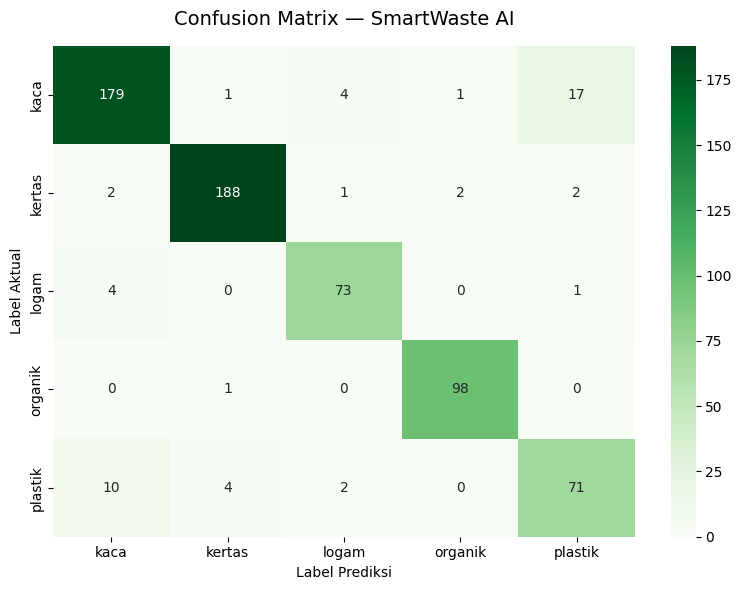

Saved: confusion_matrix.png


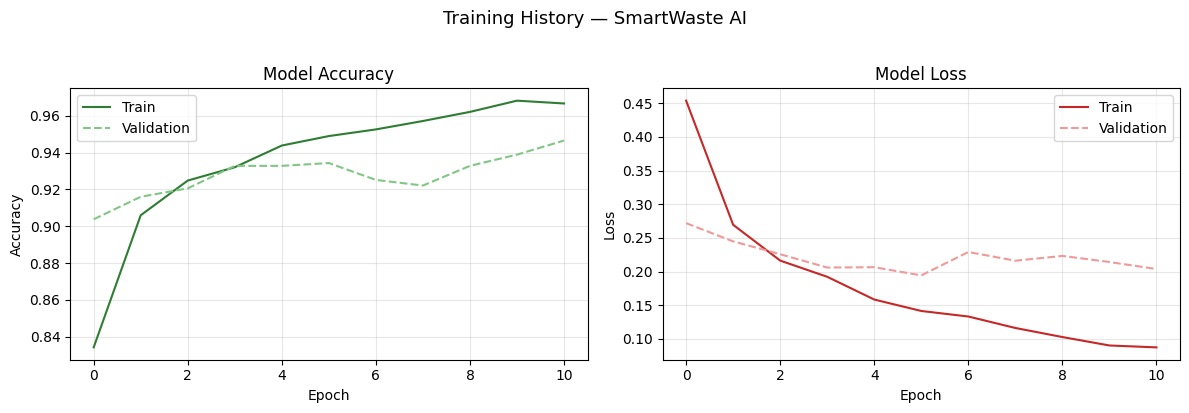

Saved: training_history.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell 9b — Plot Confusion Matrix & Training History
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Prediksi
y_pred = np.argmax(model.predict(test_data), axis=1)
y_true = test_data.classes
class_names = list(test_data.class_indices.keys())

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — SmartWaste AI', fontsize=14, pad=15)
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

# --- Plot 2: Training History ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train', color='#2e7d32')
ax1.plot(history.history['val_accuracy'], label='Validation', color='#81c784', linestyle='--')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train', color='#c62828')
ax2.plot(history.history['val_loss'], label='Validation', color='#ef9a9a', linestyle='--')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History — SmartWaste AI', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_history.png")

# --- Download semua ---
from google.colab import files
files.download('confusion_matrix.png')
files.download('training_history.png')

## 9. Simpan & download model

Disimpan sebagai `.keras` (format native Keras 3) supaya tidak kena masalah kompatibilitas config key di TensorFlow 2.16+ yang biasa terjadi pada file `.h5` lama.

In [ ]:
# Cell 10 — Simpan & download
model.save("smartwaste_mobilenetv2.keras")

from google.colab import files
files.download("smartwaste_mobilenetv2.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('confusion_matrix.png')
files.download('training_history.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json
from google.colab import files

class_indices = train_data.class_indices
with open("class_indices.json", "w") as f:
    json.dump(class_indices, f)

print("Class mapping:", class_indices)
files.download("class_indices.json")

Class mapping: {'kaca': 0, 'kertas': 1, 'logam': 2, 'organik': 3, 'plastik': 4}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Catatan untuk tahap selanjutnya

- Kalau akurasi masih kurang memuaskan, coba fine-tune dengan membuka beberapa layer terakhir `base_model` (`base_model.trainable = True` untuk ~30 layer terakhir) dan training ulang dengan learning rate kecil (misalnya 1e-5).
- Saat load model di Flask, pastikan pakai `tf.keras.models.load_model("smartwaste_mobilenetv2.keras")` — bukan `load_model(...).h5` — supaya konsisten dengan format yang disimpan di sini.
- Class mapping (`train_data.class_indices`) penting dicatat — urutan index harus sama persis antara training dan saat inference di Flask supaya label prediksi tidak tertukar.